# Text-To-Brain Generation Comparison

Notebook wrapper for the MLP NeuroVLM vs atlas-free CNN Stage 4 text-to-brain generation comparison. The evaluation code lives in `atlas_free_cnn.evaluation.compare_text_to_brain_generation`; this notebook configures and calls the actual comparison workflow, then inspects the saved output tables.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "neurovlm").exists() and (candidate / "experiments" / "3dcnn" / "atlas_free_cnn").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Start Jupyter from the neurovlm repo or update this cell.")

REPO_ROOT = find_repo_root()
THREEDCNN = REPO_ROOT / "experiments" / "3dcnn"
MODEL_COMPARISON_DIR = THREEDCNN / "model_comparison"
for path in [REPO_ROOT / "src", THREEDCNN, MODEL_COMPARISON_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

REPO_ROOT

PosixPath('/Users/borng/code/lab_work/neurovlm')

In [2]:
import pandas as pd

from atlas_free_cnn.evaluation.compare_text_to_brain_generation import (
    BY_SAMPLE_FILENAME,
    DATASETS,
    DEFAULT_OUTPUT_DIR,
    DICE_SENSITIVITY_FILENAME,
    RANDOM_BASELINE_FILENAME,
    SUMMARY_FILENAME,
    T2B_MODEL_IDS,
    run_comparison,
)

list(DATASETS), list(T2B_MODEL_IDS)

(['pubmed', 'nilearn', 'neurovault'],
 ['mlp_neurovlm',
  'cnn_t2b_mixed',
  'cnn_t2b_mixed_to_pubmed',
  'cnn_t2b_mixed_to_nilearn',
  'cnn_t2b_mixed_to_neurovault',
  'cnn_t2b_mixed_pubmed',
  'cnn_t2b_mixed_nilearn',
  'cnn_t2b_mixed_neurovault',
  'cnn_t2b_pubmed',
  'cnn_t2b_nilearn',
  'cnn_t2b_neurovault'])

## Configure

Set `RUN_MODE` below: `"quick"` is a fast sanity check (MLP on Nilearn only,
two samples, spin tests off); `"full"` is the actual comparison across all
datasets/models (downloads MLP assets, CNN Stage 4 checkpoints + matching
AEs + Stage 3 evaluators, the unified test split, and the normalized
SPECTER2 cache on first run). Everything below -- Run Comparison, Inspect
Outputs, Visualize Results -- uses whichever mode you pick here.

In [3]:
# RUN_MODE:
#   "quick" - fast sanity check: MLP only, Nilearn only, two samples, spin tests off.
#   "full"  - the actual comparison across all datasets/models.
RUN_MODE = "full"

if RUN_MODE == "quick":
    DATASETS_TO_RUN = ["nilearn"]
    MODELS = ["mlp_neurovlm"]
    LIMIT = 2
    SKIP_SPIN = True
elif RUN_MODE == "full":
    DATASETS_TO_RUN = ["pubmed", "nilearn", "neurovault"]
    MODELS = [
        "mlp_neurovlm",
        "cnn_t2b_mixed",
        "cnn_t2b_pubmed",
        "cnn_t2b_nilearn",
        "cnn_t2b_neurovault",
    ]
    LIMIT = 8
    SKIP_SPIN = True
else:
    raise ValueError(f"Unknown RUN_MODE {RUN_MODE!r}; expected 'quick' or 'full'")

DEVICE = "cpu"
BATCH_SIZE = 8
SKIP_VOXEL_AUROC = False
DICE_PCT = 90.0
DICE_SENSITIVITY_PCTS = [80.0, 85.0, 90.0, 95.0]

preferred_test_jsonl = REPO_ROOT / "experiments" / "3dcnn" / "atlas_free_cnn" / "cache" / "unified_jsonl" / "splits" / "test.jsonl"
TEST_JSONL = preferred_test_jsonl if preferred_test_jsonl.exists() else None

preferred_text_cache = REPO_ROOT / "experiments" / "3dcnn" / "atlas_free_cnn" / "cache" / "text_embeddings" / "specter2_stage3_stage4_emptycentered_unitnorm.pt"
TEXT_EMBEDDING_CACHE = preferred_text_cache if preferred_text_cache.exists() else None

OUTPUT_DIR = REPO_ROOT / DEFAULT_OUTPUT_DIR

{
    "run_mode": RUN_MODE,
    "datasets": DATASETS_TO_RUN,
    "models": MODELS,
    "limit": LIMIT,
    "device": DEVICE,
    "skip_spin": SKIP_SPIN,
    "test_jsonl": str(TEST_JSONL) if TEST_JSONL else None,
    "text_embedding_cache": str(TEXT_EMBEDDING_CACHE) if TEXT_EMBEDDING_CACHE else None,
    "output_dir": str(OUTPUT_DIR),
}

{'run_mode': 'full',
 'datasets': ['pubmed', 'nilearn', 'neurovault'],
 'models': ['mlp_neurovlm',
  'cnn_t2b_mixed',
  'cnn_t2b_pubmed',
  'cnn_t2b_nilearn',
  'cnn_t2b_neurovault'],
 'limit': 8,
 'device': 'cpu',
 'skip_spin': True,
 'test_jsonl': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/cache/unified_jsonl/splits/test.jsonl',
 'text_embedding_cache': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/cache/text_embeddings/specter2_stage3_stage4_emptycentered_unitnorm.pt',
 'output_dir': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison'}

## Run Comparison

In [4]:
result = run_comparison(
    datasets=DATASETS_TO_RUN,
    models=MODELS,
    limit=LIMIT,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    test_jsonl=TEST_JSONL,
    text_embedding_cache=TEXT_EMBEDDING_CACHE,
    batch_size=BATCH_SIZE,
    dice_pct=DICE_PCT,
    dice_sensitivity_pcts=DICE_SENSITIVITY_PCTS,
    skip_spin=SKIP_SPIN,
    spin_test_n_perm=1000,
    random_baseline_n=25,
    random_baseline_max_voxels=10000,
    random_seed=13,
    include_voxel_auroc=not SKIP_VOXEL_AUROC,
    sensitivity_jobs=1,
)

result

[fetch_atlas_harvard_oxford] Dataset found in /Users/borng/nilearn_data/fsl

/Users/borng/code/lab_work/neurovlm/src/neurovlm/text_to_brain_metrics.py:743: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_img = resample_to_img(atlas.maps, mask_img, interpolation="nearest")
/Users/borng/code/lab_work/neurovlm/src/neurovlm/text_to_brain_metrics.py:743: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  atlas_img = resample_to_img(atlas.maps, mask_img, interpolation="nearest")
There are adapters available but none are activated for the forward pass.
/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/evaluation/compare_text_to_brain_generation.py:397: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  

[fetch_atlas_harvard_oxford] Dataset found in /Users/borng/nilearn_data/fsl

/Users/borng/code/lab_work/neurovlm/src/neurovlm/text_to_brain_metrics.py:743: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_img = resample_to_img(atlas.maps, mask_img, interpolation="nearest")
/Users/borng/code/lab_work/neurovlm/src/neurovlm/text_to_brain_metrics.py:743: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  atlas_img = resample_to_img(atlas.maps, mask_img, interpolation="nearest")
There are adapters available but none are activated for the forward pass.


neurovault random correlation baseline:   0%|          | 0/32 [00:00<?, ?it/s]

...

pubmed Dice sensitivity:   0%|          | 0/8 [00:00<?, ?it/s]

pubmed Dice sensitivity:   0%|          | 0/8 [00:00<?, ?it/s]

pubmed Dice sensitivity:   0%|          | 0/8 [00:00<?, ?it/s]

pubmed Dice sensitivity:   0%|          | 0/8 [00:00<?, ?it/s]

{'by_sample_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/text_to_brain_by_sample.csv'),
 'summary_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/text_to_brain_summary.csv'),
 'random_baseline_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/text_to_brain_random_baseline.csv'),
 'dice_sensitivity_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/text_to_brain_dice_sensitivity.csv'),
 'manifest_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/text_to_brain_manifest.json'),
 'by_sample': [{'dataset': 'pubmed',
   'requested_model_id': 'mlp_neurovlm',
   'model_id': 'mlp_neurovlm',
   'model_family': 'mlp',
   'model_domain': None,
   'model_branch': None,
   'cnn_variant': '

## Inspect Outputs

In [5]:
summary = pd.read_csv(result["summary_path"])
summary

,dataset,model_id,model_family,model_domain,model_branch,checkpoint,comparison_space,status,n_samples,n_ok,...,spatial_corr_mean,spatial_corr_std,top1_dice_mean,top1_dice_std,top5_dice_mean,top5_dice_std,top10_dice_mean,top10_dice_std,voxel_auroc_mean,voxel_auroc_std
0,neurovault,cnn_t2b_mixed_to_neurovault,cnn_t2b,neurovault,baseline,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.548451,0.247841,0.079140,0.084512,0.222263,0.141183,0.323587,0.136033,0.849142,0.063752
1,neurovault,cnn_t2b_neurovault,cnn_t2b,neurovault,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.550366,0.250981,0.076907,0.095679,0.216293,0.151262,0.312480,0.136807,0.843601,0.066760
2,neurovault,cnn_t2b_nilearn,cnn_t2b,nilearn,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.268990,0.164624,0.033685,0.032838,0.148351,0.070364,0.241614,0.088082,0.697601,0.118107
3,neurovault,cnn_t2b_pubmed,cnn_t2b,pubmed,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.246725,0.138868,0.082589,0.095491,0.184007,0.114278,0.271199,0.106228,0.683410,0.141714
4,neurovault,mlp_neurovlm,mlp,NaN,NaN,NaN,mlp_masker_flatmap,ok,8,8,...,0.124448,0.168733,0.041521,0.086877,0.134804,0.135381,0.213879,0.161621,0.649789,0.207777
5,nilearn,cnn_t2b_mixed_to_nilearn,cnn_t2b,nilearn,baseline,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.019664,0.032820,0.003247,0.006287,0.008203,0.009230,0.045443,0.013456,0.665472,0.183705
6,nilearn,cnn_t2b_neurovault,cnn_t2b,neurovault,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.008577,0.010428,0.000406,0.001074,0.007554,0.012300,0.045179,0.022818,0.753660,0.088361
7,nilearn,cnn_t2b_nilearn,cnn_t2b,nilearn,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.050022,0.057652,0.020495,0.033239,0.028793,0.032496,0.075069,0.023450,0.721357,0.189134
8,nilearn,cnn_t2b_pubmed,cnn_t2b,pubmed,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.067853,0.103976,0.032873,0.073871,0.033910,0.075875,0.038661,0.046804,0.872816,0.106168
9,nilearn,mlp_neurovlm,mlp,NaN,NaN,NaN,NaN,unsupported_dataset,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
metric_cols = [
    "dataset",
    "requested_model_id",
    "model_id",
    "model_family",
    "status",
    "n_samples",
    "n_ok",
    "pearson_r_mean",
    "spearman_rho_mean",
    "dice_pct90_mean",
    "generated_image_text_normalized_auc_mean",
    "mse_mean",
    "foreground_mse_mean",
    "spatial_corr_mean",
    "checkpoint",
    "skip_reasons",
]
available = [col for col in metric_cols if col in summary.columns]
summary[available] if available else summary

,dataset,model_id,model_family,status,n_samples,n_ok,pearson_r_mean,spearman_rho_mean,dice_pct90_mean,generated_image_text_normalized_auc_mean,mse_mean,foreground_mse_mean,spatial_corr_mean,checkpoint,skip_reasons
0,neurovault,cnn_t2b_mixed_to_neurovault,cnn_t2b,ok,8,8,0.548794,0.605214,0.321765,0.640625,0.021102,0.096233,0.548451,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
1,neurovault,cnn_t2b_neurovault,cnn_t2b,ok,8,8,0.550475,0.600490,0.307279,0.656250,0.020874,0.093378,0.550366,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
2,neurovault,cnn_t2b_nilearn,cnn_t2b,ok,8,8,0.270642,0.378371,0.238855,0.593750,0.050927,0.190814,0.268990,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
3,neurovault,cnn_t2b_pubmed,cnn_t2b,ok,8,8,0.251114,0.345624,0.264329,0.828125,0.051583,0.192541,0.246725,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
4,neurovault,mlp_neurovlm,mlp,ok,8,8,0.124448,0.233623,0.213879,0.812500,0.006001,0.006001,0.124448,NaN,NaN
5,nilearn,cnn_t2b_mixed_to_nilearn,cnn_t2b,ok,8,8,0.019514,0.020286,0.009343,0.562500,0.001062,0.772871,0.019664,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
6,nilearn,cnn_t2b_neurovault,cnn_t2b,ok,8,8,0.008894,0.031354,0.011100,0.562500,0.004494,0.711200,0.008577,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
7,nilearn,cnn_t2b_nilearn,cnn_t2b,ok,8,8,0.042035,0.034391,0.021182,0.546875,0.001061,0.769679,0.050022,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
8,nilearn,cnn_t2b_pubmed,cnn_t2b,ok,8,8,0.068010,0.058186,0.036685,0.859375,0.001072,0.759775,0.067853,/Users/borng/.cache/huggingface/hub/models--ne...,NaN
9,nilearn,mlp_neurovlm,mlp,unsupported_dataset,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main_neurovlm_flat_nilearn_resource_unavailable


## Visualize Results

Same fixed model-family colors as the other two comparison notebooks. The
top row compares dataset/model means from the summary table; the box plots
below show the full per-sample Pearson r distribution (median/IQR are more
informative than a mean for a noisy per-sample metric), and the last figure
shows Dice overlap sensitivity across percentile thresholds instead of a
single fixed cutoff.

In [7]:
import matplotlib.pyplot as plt
import plotting_utils as pu

pu.coverage_table(summary)

dataset,neurovault,nilearn,pubmed
model_id,,,
cnn_t2b_mixed_to_neurovault,ok,no_row,no_row
cnn_t2b_mixed_to_nilearn,no_row,ok,no_row
cnn_t2b_mixed_to_pubmed,no_row,no_row,ok
cnn_t2b_neurovault,ok,ok,ok
cnn_t2b_nilearn,ok,ok,ok
cnn_t2b_pubmed,ok,ok,ok
mlp_neurovlm,ok,unsupported_dataset,ok


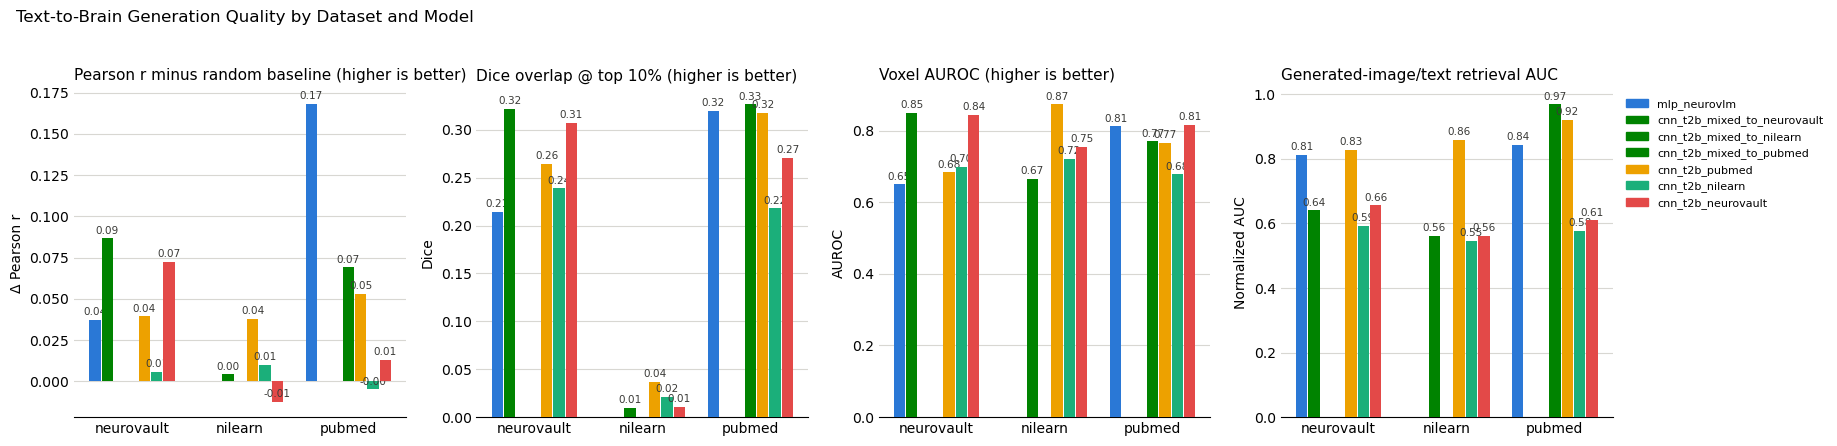

In [8]:
fig_metrics, axes = plt.subplots(1, 4, figsize=(21, 4.5))
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="pearson_minus_random_mean",
    ax=axes[0], title="Pearson r minus random baseline (higher is better)", ylabel="Δ Pearson r", show_legend=False,
)
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="dice_pct90_mean",
    ax=axes[1], title="Dice overlap @ top 10% (higher is better)", ylabel="Dice", show_legend=False,
)
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="voxel_auroc_mean",
    ax=axes[2], title="Voxel AUROC (higher is better)", ylabel="AUROC", show_legend=False,
)
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="generated_image_text_normalized_auc_mean",
    ax=axes[3], title="Generated-image/text retrieval AUC", ylabel="Normalized AUC",
)
fig_metrics.suptitle("Text-to-Brain Generation Quality by Dataset and Model", x=0.01, ha="left", fontsize=12)
fig_metrics.tight_layout(rect=(0, 0, 0.88, 0.95))

In [9]:
by_sample = pd.read_csv(result["by_sample_path"])
by_sample.head(20)

,dataset,requested_model_id,model_id,model_family,model_domain,model_branch,cnn_variant,status,checkpoint,checkpoint_error,...,pearson_random_percentile,spearman_baseline_actual,spearman_random_mean,spearman_random_std,spearman_minus_random,spearman_random_percentile,random_baseline_n,random_baseline_n_voxels,random_baseline_group_dataset,random_baseline_group_model_family
0,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.538462,0.088156,0.323906,0.178796,-0.235751,0.038462,25.0,10000.0,pubmed,mlp
1,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.269231,0.320755,0.362370,0.230546,-0.041615,0.461538,25.0,10000.0,pubmed,mlp
2,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.884615,0.563507,0.294791,0.284366,0.268717,0.807692,25.0,10000.0,pubmed,mlp
3,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,1.000000,0.609693,0.250442,0.185396,0.359251,1.000000,25.0,10000.0,pubmed,mlp
4,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,1.000000,0.652034,0.227364,0.241529,0.424669,1.000000,25.0,10000.0,pubmed,mlp
5,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,1.000000,0.725274,0.284559,0.245178,0.440715,1.000000,25.0,10000.0,pubmed,mlp
6,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.769231,0.433809,0.321234,0.230461,0.112574,0.653846,25.0,10000.0,pubmed,mlp
7,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.730769,0.139568,0.306998,0.287527,-0.167430,0.192308,25.0,10000.0,pubmed,mlp
8,pubmed,cnn_t2b_mixed,cnn_t2b_mixed_to_pubmed,cnn_t2b,pubmed,baseline,mixed_to_pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.884615,0.417118,0.257760,0.087790,0.159358,0.884615,25.0,10000.0,pubmed,cnn_t2b
9,pubmed,cnn_t2b_mixed,cnn_t2b_mixed_to_pubmed,cnn_t2b,pubmed,baseline,mixed_to_pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.769231,0.226872,0.274558,0.054826,-0.047686,0.192308,25.0,10000.0,pubmed,cnn_t2b


In [10]:
random_path = result["random_baseline_path"]
random_baseline = pd.read_csv(random_path) if random_path.exists() and random_path.stat().st_size else pd.DataFrame()
random_baseline.head(20)

,dataset,model_family,model_id,sample_id,comparison_space,pearson_baseline_actual,pearson_random_mean,pearson_random_std,pearson_minus_random,pearson_random_percentile,spearman_baseline_actual,spearman_random_mean,spearman_random_std,spearman_minus_random,spearman_random_percentile,random_baseline_n,random_baseline_n_voxels,random_baseline_group_dataset,random_baseline_group_model_family
0,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_13877,native_atlas_free_volume,0.843280,0.498067,0.235750,0.345212,0.923077,0.840153,0.571823,0.220391,0.268330,0.923077,25,10000,neurovault,cnn_t2b
1,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_13883,native_atlas_free_volume,0.832689,0.487095,0.219609,0.345594,0.807692,0.834284,0.564588,0.202410,0.269695,0.807692,25,10000,neurovault,cnn_t2b
2,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_13894,native_atlas_free_volume,0.025280,0.445906,0.190072,-0.420626,0.038462,0.112891,0.582535,0.205515,-0.469644,0.038462,25,10000,neurovault,cnn_t2b
3,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_15571,native_atlas_free_volume,0.399857,0.432123,0.210779,-0.032266,0.269231,0.662513,0.562523,0.243362,0.099991,0.461538,25,10000,neurovault,cnn_t2b
4,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_8746,native_atlas_free_volume,0.699175,0.426562,0.225540,0.272613,0.884615,0.712285,0.550974,0.236073,0.161310,0.653846,25,10000,neurovault,cnn_t2b
5,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_546,native_atlas_free_volume,0.432998,0.474456,0.238495,-0.041458,0.192308,0.423770,0.576713,0.249998,-0.152943,0.192308,25,10000,neurovault,cnn_t2b
6,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_14039,native_atlas_free_volume,0.614742,0.384306,0.228933,0.230436,0.730769,0.669476,0.551403,0.232449,0.118073,0.653846,25,10000,neurovault,cnn_t2b
7,neurovault,cnn_t2b,cnn_t2b_mixed_to_neurovault,neurovault_14045,native_atlas_free_volume,0.498449,0.504248,0.180280,-0.005799,0.269231,0.586420,0.588847,0.181476,-0.002427,0.269231,25,10000,neurovault,cnn_t2b
8,neurovault,cnn_t2b,cnn_t2b_pubmed,neurovault_13877,native_atlas_free_volume,0.248806,0.212142,0.126641,0.036664,0.538462,0.526315,0.394078,0.201685,0.132237,0.653846,25,10000,neurovault,cnn_t2b
9,neurovault,cnn_t2b,cnn_t2b_pubmed,neurovault_13883,native_atlas_free_volume,0.263735,0.243048,0.151489,0.020687,0.384615,0.529776,0.401462,0.207719,0.128314,0.769231,25,10000,neurovault,cnn_t2b


In [11]:
dice_path = result["dice_sensitivity_path"]
dice_sensitivity = pd.read_csv(dice_path) if dice_path.exists() and dice_path.stat().st_size else pd.DataFrame()
dice_sensitivity.head(20)

,dataset,model_id,comparison_space,sample_id,status,pct,top_fraction,dice,spin_p_value,spin_significant,method,skip_reason
0,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13877,ok,80.0,0.20,0.553677,NaN,False,volume_masker_percentile,NaN
1,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13877,ok,85.0,0.15,0.407668,NaN,False,volume_masker_percentile,NaN
2,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13877,ok,90.0,0.10,0.252158,NaN,False,volume_masker_percentile,NaN
3,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13877,ok,95.0,0.05,0.109180,NaN,False,volume_masker_percentile,NaN
4,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13883,ok,80.0,0.20,0.580331,NaN,False,volume_masker_percentile,NaN
5,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13883,ok,85.0,0.15,0.444733,NaN,False,volume_masker_percentile,NaN
6,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13883,ok,90.0,0.10,0.317953,NaN,False,volume_masker_percentile,NaN
7,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13883,ok,95.0,0.05,0.194314,NaN,False,volume_masker_percentile,NaN
8,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13894,ok,80.0,0.20,0.067974,NaN,False,volume_masker_percentile,NaN
9,neurovault,cnn_t2b_mixed_to_neurovault,native_atlas_free_volume,neurovault_13894,ok,85.0,0.15,0.061479,NaN,False,volume_masker_percentile,NaN


### Per-Sample Distributions And Threshold Sensitivity

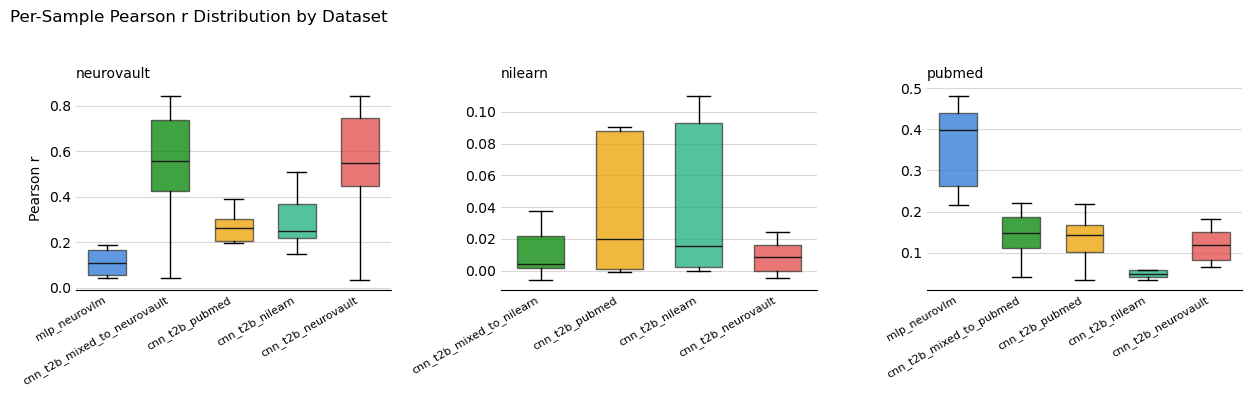

In [12]:
fig_dist = pu.sample_distribution_box(
    by_sample, panel_col="dataset", series_col="model_id", value_col="pearson_r",
    suptitle="Per-Sample Pearson r Distribution by Dataset", ylabel="Pearson r",
)

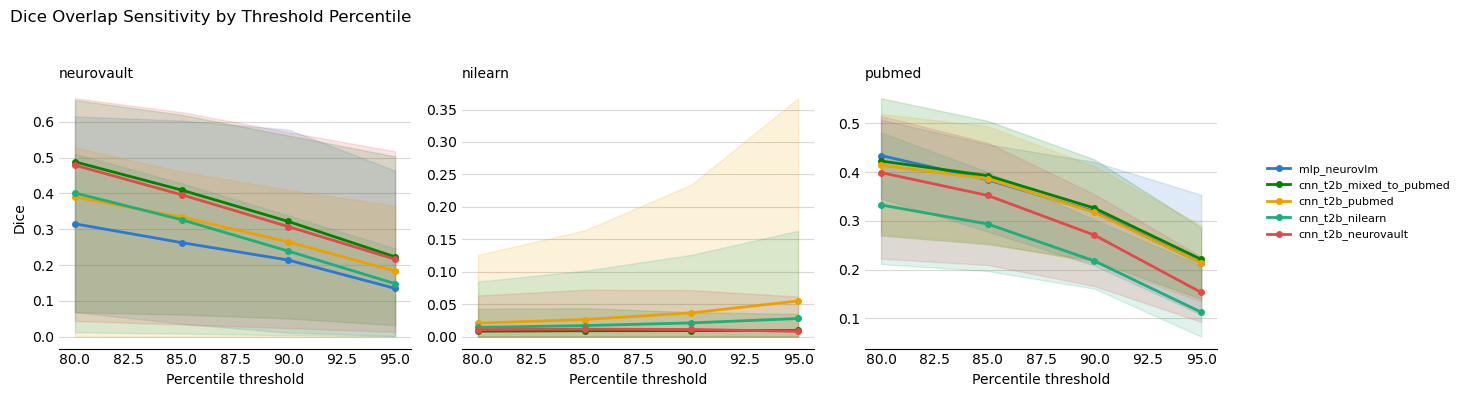

In [13]:
fig_dice = pu.small_multiples_lines(
    dice_sensitivity, panel_col="dataset", x_col="pct", y_col="dice", series_col="model_id",
    suptitle="Dice Overlap Sensitivity by Threshold Percentile", xlabel="Percentile threshold", ylabel="Dice",
    aggregate="mean", show_range=True,
)

## Existing Output Loader

Use this cell when you have already run the CLI or a previous notebook cell and only want to inspect the saved CSVs.

In [14]:
saved_by_sample = OUTPUT_DIR / BY_SAMPLE_FILENAME
saved_summary = OUTPUT_DIR / SUMMARY_FILENAME
saved_random = OUTPUT_DIR / RANDOM_BASELINE_FILENAME
saved_dice = OUTPUT_DIR / DICE_SENSITIVITY_FILENAME

loaded_by_sample = pd.read_csv(saved_by_sample) if saved_by_sample.exists() and saved_by_sample.stat().st_size else pd.DataFrame()
loaded_summary = pd.read_csv(saved_summary) if saved_summary.exists() and saved_summary.stat().st_size else pd.DataFrame()
loaded_random = pd.read_csv(saved_random) if saved_random.exists() and saved_random.stat().st_size else pd.DataFrame()
loaded_dice = pd.read_csv(saved_dice) if saved_dice.exists() and saved_dice.stat().st_size else pd.DataFrame()

loaded_summary.head(20)

,dataset,model_id,model_family,model_domain,model_branch,checkpoint,comparison_space,status,n_samples,n_ok,...,spatial_corr_mean,spatial_corr_std,top1_dice_mean,top1_dice_std,top5_dice_mean,top5_dice_std,top10_dice_mean,top10_dice_std,voxel_auroc_mean,voxel_auroc_std
0,neurovault,cnn_t2b_mixed_to_neurovault,cnn_t2b,neurovault,baseline,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.548451,0.247841,0.079140,0.084512,0.222263,0.141183,0.323587,0.136033,0.849142,0.063752
1,neurovault,cnn_t2b_neurovault,cnn_t2b,neurovault,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.550366,0.250981,0.076907,0.095679,0.216293,0.151262,0.312480,0.136807,0.843601,0.066760
2,neurovault,cnn_t2b_nilearn,cnn_t2b,nilearn,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.268990,0.164624,0.033685,0.032838,0.148351,0.070364,0.241614,0.088082,0.697601,0.118107
3,neurovault,cnn_t2b_pubmed,cnn_t2b,pubmed,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.246725,0.138868,0.082589,0.095491,0.184007,0.114278,0.271199,0.106228,0.683410,0.141714
4,neurovault,mlp_neurovlm,mlp,NaN,NaN,NaN,mlp_masker_flatmap,ok,8,8,...,0.124448,0.168733,0.041521,0.086877,0.134804,0.135381,0.213879,0.161621,0.649789,0.207777
5,nilearn,cnn_t2b_mixed_to_nilearn,cnn_t2b,nilearn,baseline,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.019664,0.032820,0.003247,0.006287,0.008203,0.009230,0.045443,0.013456,0.665472,0.183705
6,nilearn,cnn_t2b_neurovault,cnn_t2b,neurovault,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.008577,0.010428,0.000406,0.001074,0.007554,0.012300,0.045179,0.022818,0.753660,0.088361
7,nilearn,cnn_t2b_nilearn,cnn_t2b,nilearn,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.050022,0.057652,0.020495,0.033239,0.028793,0.032496,0.075069,0.023450,0.721357,0.189134
8,nilearn,cnn_t2b_pubmed,cnn_t2b,pubmed,specialized,/Users/borng/.cache/huggingface/hub/models--ne...,native_atlas_free_volume,ok,8,8,...,0.067853,0.103976,0.032873,0.073871,0.033910,0.075875,0.038661,0.046804,0.872816,0.106168
9,nilearn,mlp_neurovlm,mlp,NaN,NaN,NaN,NaN,unsupported_dataset,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Export For Report

Save every figure and dataframe from this run into one directory (PNG +
CSV, plus a `manifest.json` listing them), so an HTML-report builder can
read a single, predictable location instead of re-running the comparison.

In [15]:
REPORT_ASSETS_DIR = OUTPUT_DIR / "report_assets" / "text_to_brain_generation"

report_manifest = pu.save_report_assets(
    REPORT_ASSETS_DIR,
    figures={
        "text_to_brain_metrics": fig_metrics,
        "text_to_brain_pearson_distribution": fig_dist,
        "text_to_brain_dice_sensitivity": fig_dice,
    },
    dataframes={
        "text_to_brain_summary": summary,
        "text_to_brain_by_sample": by_sample,
        "text_to_brain_random_baseline": random_baseline,
        "text_to_brain_dice_sensitivity": dice_sensitivity,
    },
)
report_manifest

{'figures': {'text_to_brain_metrics': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/text_to_brain_generation/text_to_brain_metrics.png',
  'text_to_brain_pearson_distribution': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/text_to_brain_generation/text_to_brain_pearson_distribution.png',
  'text_to_brain_dice_sensitivity': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/text_to_brain_generation/text_to_brain_dice_sensitivity.png'},
 'dataframes': {'text_to_brain_summary': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/text_to_brain_generation/text_to_brain_summary.csv',
  'text_to_brain_by_sample': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/text_to_brain_generation/text_to_bra